In [17]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [19]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(vocab_size)

27


In [20]:
# build dataset for different splits
block_size = 3       # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8* len(words))
n2 = int(0.9* len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [21]:
# MLP revisited

n_embd = 10     # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)  * (5/3)/(n_embd * block_size)  # std dev
b1 = torch.randn(n_hidden, generator=g)  * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # for fixin initial high loss error, dont set to 0, just small. -----|______ Making sure logits are closer to 0 for low initial loss
b2 = torch.randn(vocab_size, generator=g) * 0  # for fixin initial high loss error  ----------------------------------------------|

# for scaling and adding bias to batch normalization 
# Batch norm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
# buffers of batch norm
bnmean_running = torch.zeros((1, n_hidden)) # -----|_____ Not part of gradient based optimization, no gradient calculations for them, but rather will be updated on the side
bnstd_running = torch.ones((1, n_hidden))   # -----|

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))    # number of total parameters
for p in parameters:
    p.requires_grad = True

12297


tensor(0.0017) tensor(0.9986)
tensor(0.0032) tensor(1.0174)


(array([2.17390160e-05, 1.30434096e-04, 1.30434096e-04, 3.69563271e-04,
        5.21736383e-04, 9.78255718e-04, 1.73912128e-03, 2.04346750e-03,
        4.41302024e-03, 6.10866348e-03, 1.01521205e-02, 1.67390423e-02,
        2.81955037e-02, 3.98476163e-02, 6.23040197e-02, 9.11951719e-02,
        1.27912370e-01, 1.71064317e-01, 2.27846626e-01, 2.92585416e-01,
        3.49324247e-01, 4.05410909e-01, 4.18715186e-01, 4.22258646e-01,
        3.83519720e-01, 3.31063474e-01, 2.63781220e-01, 2.06498913e-01,
        1.51107900e-01, 1.08064648e-01, 7.78474161e-02, 5.25866796e-02,
        3.42172111e-02, 2.19346671e-02, 1.50216600e-02, 8.34778213e-03,
        5.69562218e-03, 3.06520125e-03, 1.78259931e-03, 1.45651407e-03,
        6.52170479e-04, 3.47824255e-04, 3.91302287e-04, 1.30434096e-04,
        1.73912128e-04, 2.17390160e-05, 2.17390160e-05, 4.34780319e-05,
        0.00000000e+00, 2.17390160e-05]),
 array([-5.23953485, -5.00953364, -4.77953243, -4.54953122, -4.31953001,
        -4.0895288 , 

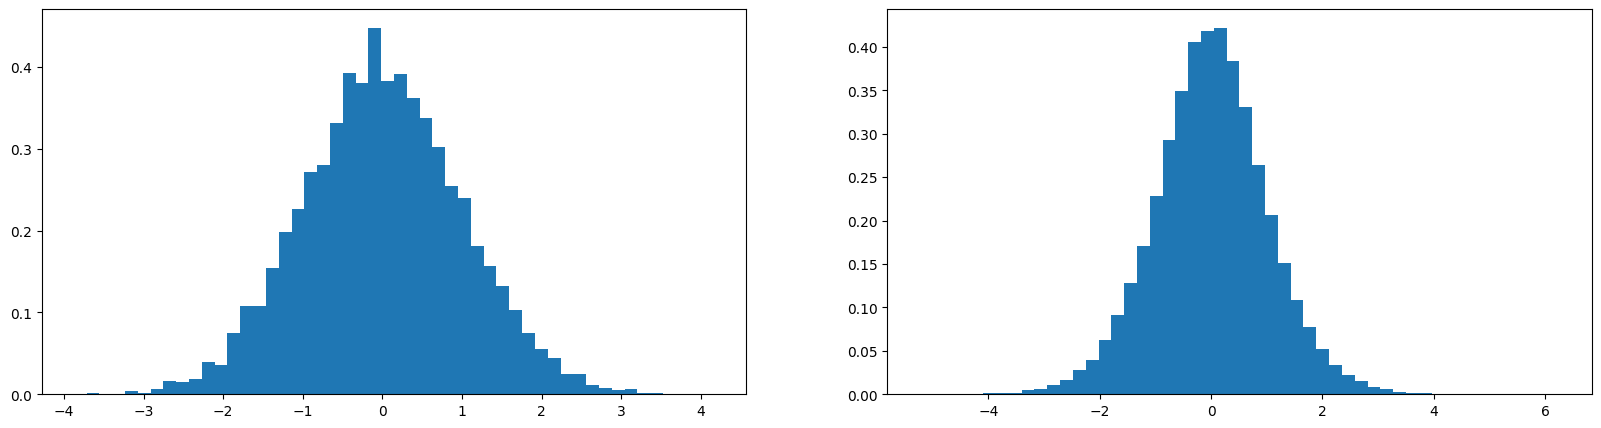

In [22]:
x = torch.randn(1000, 10)     # 1000 example, 10 dimensional
w = torch.randn(10, 200) / 10 ** 0.5     # 10 inputs, 200 neurons in hidden layer / square root (fanon)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [23]:
# batch normalization

In [24]:
hpreact.shape

NameError: name 'hpreact' is not defined

In [ ]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [ ]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [ ]:
# customary to append batch normalzation to linear layer or convolutional layers to control the scale of the activations
# function of not only one example, but other examples are also coupled together. causing h to jitter, introducing some entropy. (regularizing effect)
# biases are somewhat useless, in hpreact = embcat @ W1 + b1, because they will be subtracted out in, hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias, and batch norm has its own biases
# b1.grad will be 0.

In [ ]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []
epsilon = 0.00001  # for the case, when variance is 0, in normalization

for i in range(max_steps):

    # minibatch contruct
    index = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g) # generating a tuple of numbers between 0 and X.shape[0]
    Xb, Yb = Xtr[index], Ytr[index]  # batch X, Y

    # forward pass
    emb = C[Xtr[index]] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hpreact = embcat @ W1 # + b1          # hidden layer pre-activation
    # Batch normalization layer
    # ---------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias + epsilon  # we need them roughly gaussian, but only at initialization
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani    # momentum = 0.001
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # ---------------------------------------------------------------
    
    # Non-Linearity
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ W2 + b2     # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01   # step learning decay
    for p in parameters:
        p.data += -lr * p.grad    # for finding optimal lr, use lr instead 0.1 
    
    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1471
  20000/ 200000: 2.2606
  30000/ 200000: 2.4550
  40000/ 200000: 1.9365
  50000/ 200000: 2.3602
  60000/ 200000: 2.3991
  70000/ 200000: 2.1019
  80000/ 200000: 2.3497
  90000/ 200000: 2.1427
 100000/ 200000: 1.8667
 110000/ 200000: 2.2814
 120000/ 200000: 1.9126
 130000/ 200000: 2.5292
 140000/ 200000: 2.3574
 150000/ 200000: 2.1659
 160000/ 200000: 1.9289
 170000/ 200000: 1.8479
 180000/ 200000: 2.0889
 190000/ 200000: 1.8523


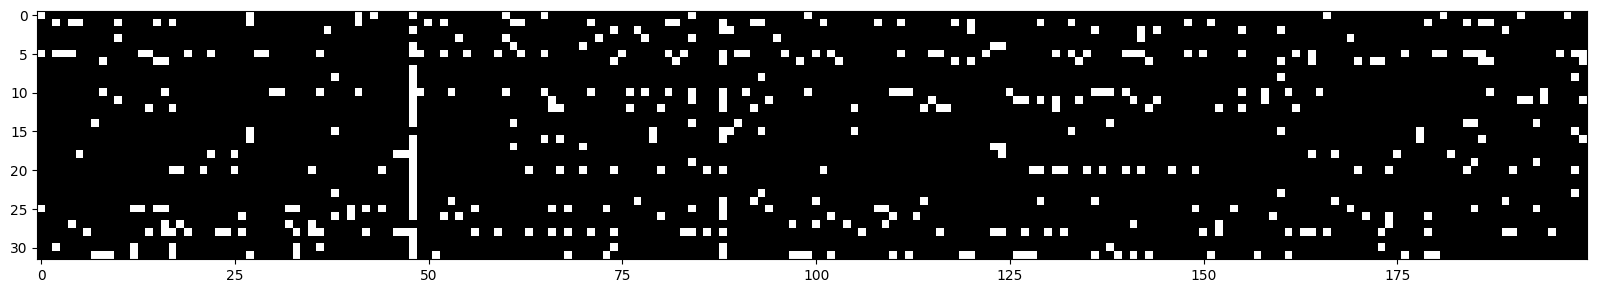

In [ ]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

(array([530., 248., 158., 181., 145., 115., 127.,  97.,  94.,  95., 102.,
         91., 111.,  70.,  85., 128.,  96.,  88.,  76., 117., 108., 106.,
        120.,  80., 118., 111., 105.,  85.,  91.,  97., 100.,  90.,  93.,
        103., 119.,  97.,  96.,  81.,  82., 100.,  69.,  99., 114., 107.,
        137., 119., 169., 165., 211., 474.]),
 array([-9.99999940e-01, -9.60003996e-01, -9.20008051e-01, -8.80012107e-01,
        -8.40016162e-01, -8.00020218e-01, -7.60024273e-01, -7.20028329e-01,
        -6.80032384e-01, -6.40036440e-01, -6.00040495e-01, -5.60044551e-01,
        -5.20048606e-01, -4.80052662e-01, -4.40056717e-01, -4.00060773e-01,
        -3.60064828e-01, -3.20068884e-01, -2.80072939e-01, -2.40076995e-01,
        -2.00081050e-01, -1.60085106e-01, -1.20089161e-01, -8.00932169e-02,
        -4.00972724e-02, -1.01327896e-04,  3.98946166e-02,  7.98905611e-02,
         1.19886506e-01,  1.59882450e-01,  1.99878395e-01,  2.39874339e-01,
         2.79870284e-01,  3.19866228e-01,  3.59862

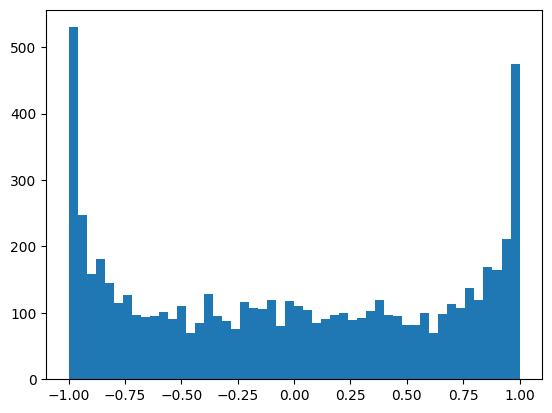

In [ ]:
# iniital values of activation of hidden states (h)
h
plt.hist(h.view(-1).tolist(), 50)
# a lot of em are 1, -1. Tanh is a squashing function, compressing values into [0, 1]
# this has an effect of grad of tanh during backpropagate comes very close to 0

# you can change the input values but minimal change in output of tanh, in the flat region
# tanh is inactive, back gradient just get destroyed.
# sometimes we have dead neuron, no example would activate it. no learning.

(array([  1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          4.,   1.,   5.,   6.,   7.,  13.,  21.,  20.,  25.,  41.,  64.,
         76.,  97., 138., 174., 192., 280., 336., 353., 501., 605., 683.,
        576., 467., 362., 301., 265., 173., 156., 115.,  92.,  76.,  54.,
         50.,  27.,  15.,  11.,   7.,   8.]),
 array([-8.51246929, -8.25025209, -7.9880349 , -7.7258177 , -7.4636005 ,
        -7.2013833 , -6.93916611, -6.67694891, -6.41473171, -6.15251451,
        -5.89029732, -5.62808012, -5.36586292, -5.10364573, -4.84142853,
        -4.57921133, -4.31699413, -4.05477694, -3.79255974, -3.53034254,
        -3.26812534, -3.00590815, -2.74369095, -2.48147375, -2.21925655,
        -1.95703936, -1.69482216, -1.43260496, -1.17038776, -0.90817057,
        -0.64595337, -0.38373617, -0.12151897,  0.14069822,  0.40291542,
         0.66513262,  0.92734982,  1.18956701,  1.45178421,  1.71400141,
         1.97621861,  2.2384358 ,  2.500653  ,  2.7628702 ,  3.02508739,
 

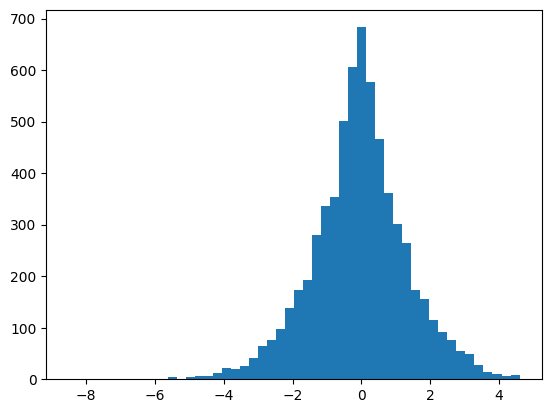

In [ ]:
plt.hist(hpreact.view(-1).tolist(), 50)  # very broad values

In [ ]:
# very high initialization loss, the probability distribution should be uniform (1/27), but isnt. Some characters have very high probability, some don't

In [ ]:
# 4D example of the issue
# logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4) * 10  # need not be low, just equal would also be fine, because of normalization 
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

# when logits take extreme values then they have false over confidence

(tensor([-14.0727,   1.2267,   0.0745,  14.6759]),
 tensor([3.2705e-13, 1.4423e-06, 4.5569e-07, 1.0000e+00]),
 tensor(14.6015))

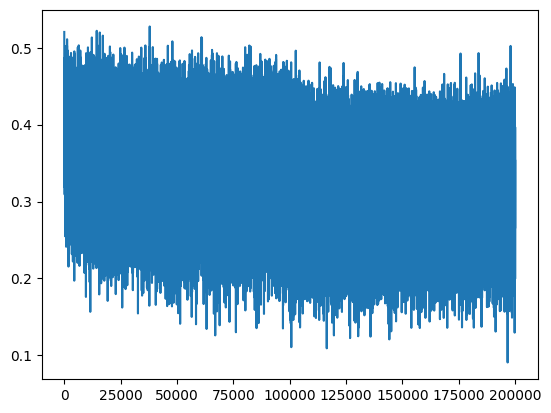

In [ ]:
plt.plot(lossi)

In [ ]:
# separate step, calibrate the batch norm at the end of training
# integrated during training, no need to run again

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [ ]:
@torch.no_grad()  # disabled gradient tracking for efficiency
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    } [split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embed)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    hpreact = bngain * (bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(embcat @ W1 + b1)    # (N, n_hidden)
    logits = h @ W2 + b2                # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.0179126262664795
val 3.061859369277954


In [ ]:
# usual: linear layer -> batch norm -> relu/tanh (non - linearity), stacked multiple of these.
# roughly gaussian activations throughout the neural net
# batch norm is deprecated now, it couples example in the forward pass. 

In [ ]:
# implementing batch norm elements form pytorch

In [71]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
         self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5 # kaiming initialization
         self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)  # bngain
        self.beta = torch.zeros(dim)  # bnbias
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers (using exponential moving average)
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1- self.momentum) * self.running_var + self.momentum * xvar
            return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [72]:
n_embd = 10 # dimensionality of the chharacter embedding vector
n_hidden = 100 # number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    # layers[-1].weight *= 0.1 # without batch norm
    layers[-1].gamma *= 0.1
    # all other layers: apply again
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))  # number of total parameters
for p in parameters:
    p.requires_grad = True

47551


In [73]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []
epsilon = 0.00001  # for the case, when variance is 0, in normalization
ud = []  # update to data 

for i in range(max_steps):

    # minibatch contruct (sampling batch)
    index = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[index], Ytr[index]

    # forward pass
    emb = C[Xtr[index]]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # After Debug: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad 

    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    if i > 1000:
        break

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.97%
layer 5 (      Tanh): mean +0.01, std 0.64, saturated: 2.41%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.44%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 2.22%
layer 14 (      Tanh): mean -0.00, std 0.64, saturated: 2.25%


Text(0.5, 1.0, 'activation distribution')

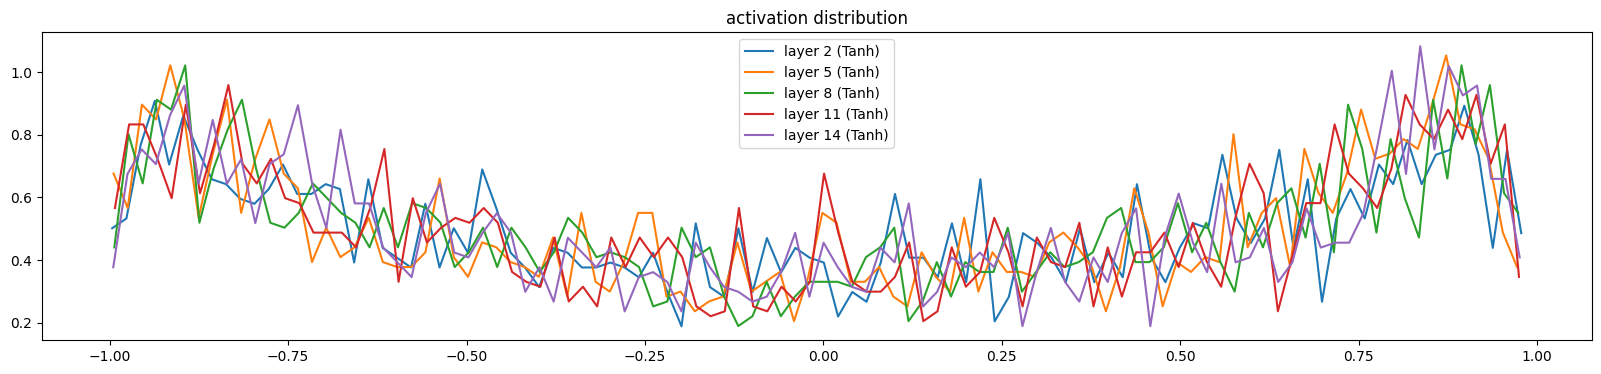

In [74]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh): # tanh for easy visualization
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.00, std 0.00
layer 5 (      Tanh): mean -0.00, std 0.00
layer 8 (      Tanh): mean +0.00, std 0.00
layer 11 (      Tanh): mean +0.00, std 0.00
layer 14 (      Tanh): mean +0.00, std 0.00


Text(0.5, 1.0, 'gradient distribution')

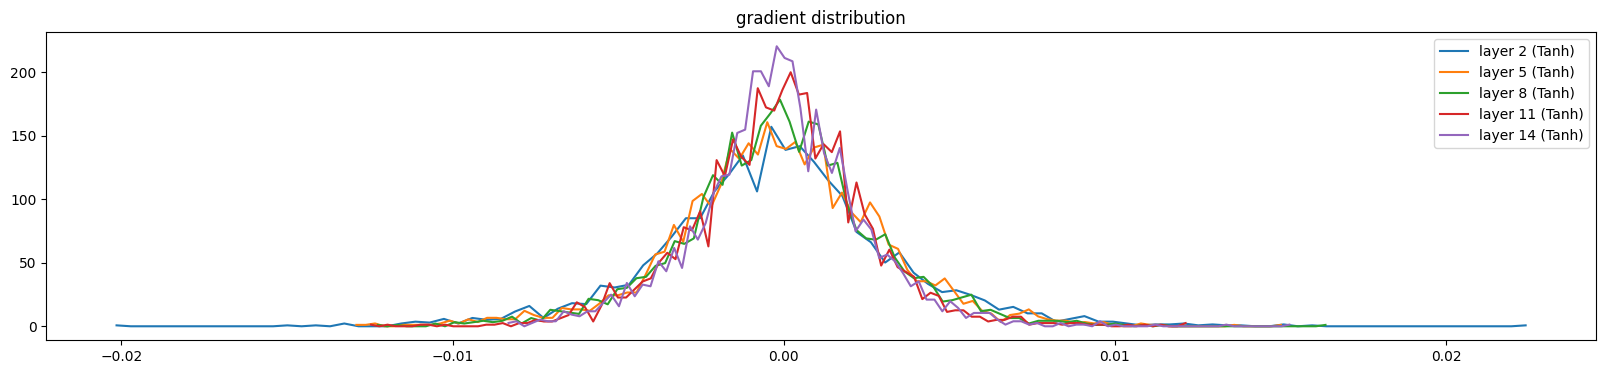

In [75]:
# visualize histograms for gradient
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh): # tanh for easy visualization
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %.2f' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

In [76]:
# why non linearity?
# if we stacked a lot of linear layers, the resultant forward pass would effectively be just a linear layer, just (w's)x + b's

weight   (27, 10) | mean -0.000000 | std 8.198658e-03 | grad:data ratio 8.190299e-03
weight  (30, 100) | mean -0.000195 | std 7.650399e-03 | grad:data ratio 2.447698e-02
weight (100, 100) | mean -0.000097 | std 6.207576e-03 | grad:data ratio 3.712878e-02
weight (100, 100) | mean +0.000015 | std 5.561921e-03 | grad:data ratio 3.297630e-02
weight (100, 100) | mean +0.000008 | std 5.220603e-03 | grad:data ratio 3.110152e-02
weight (100, 100) | mean +0.000029 | std 4.829163e-03 | grad:data ratio 2.876370e-02
weight  (100, 27) | mean -0.000014 | std 9.281216e-03 | grad:data ratio 5.568818e-02


Text(0.5, 1.0, 'weights gradient distribution')

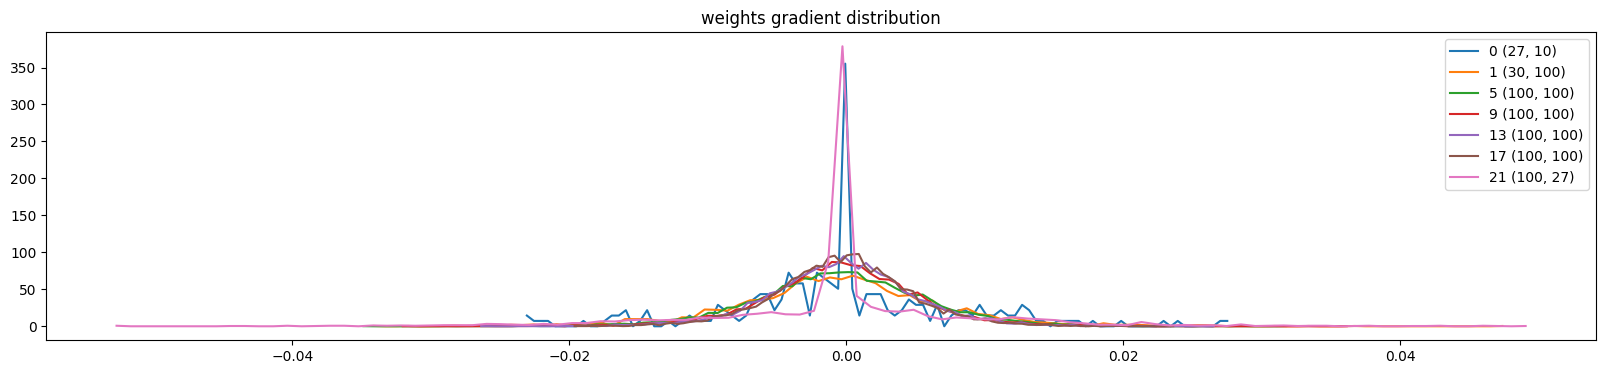

In [81]:
# visualize histograms for weights 
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape),  t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')

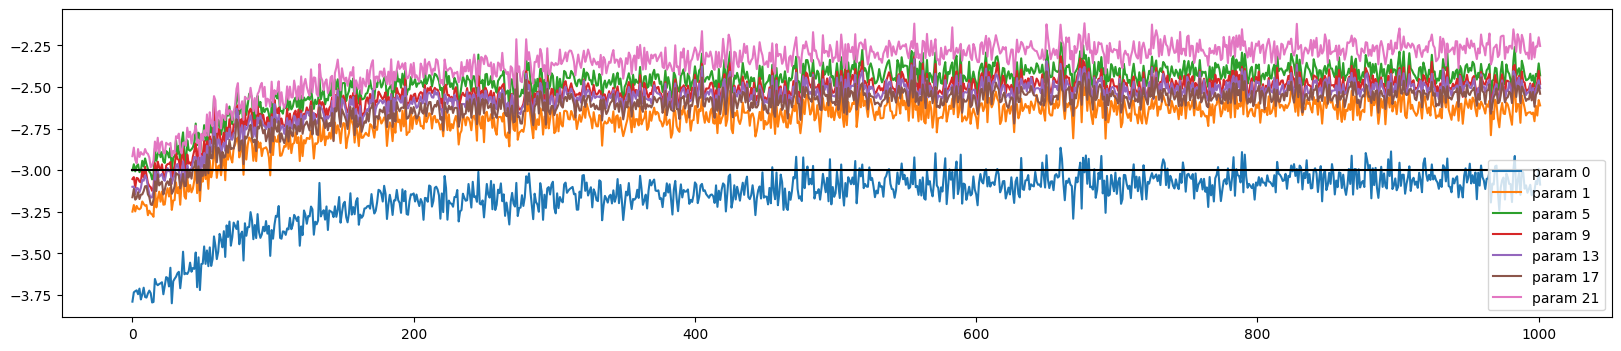

In [80]:
# visualize histograms for updates
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should ~1e-3, indicate on plot
plt.legend(legends)